## **Computación Cuántica II**
# Sebastián González Juárez

Primer examen parcial


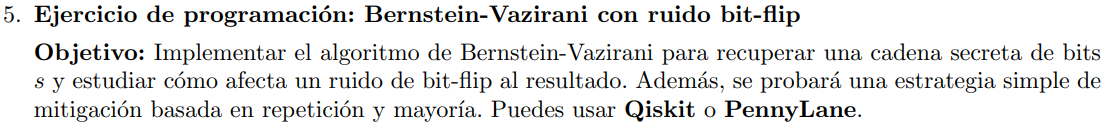

In [1]:
!pip -q install qiskit qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=719352695d88035cf44f4bbd2ceb71127a7e46551edb6e25ba94a7898a201e5b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import random
from collections import Counter

import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from collections import Counter


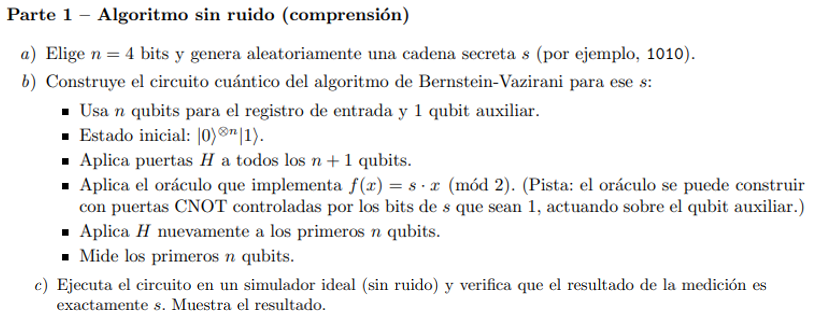

El algoritmo de Bernstein–Vazirani considera una función

$$
f(x)=s\cdot x \pmod 2,
$$

sinedo $s$ es una cadena secreta de $n$ bits. En el caso ideal, el algoritmo recupera $s$ con una sola consulta al oráculo.

Para este ejercicio usamos $n=4$. El registro de entrada tiene 4 qubits y además se usa un qubit auxiliar. El estado inicial es

$$
|0\rangle^{\otimes n}|1\rangle.
$$

Después se aplican Hadamards a todos los qubits, luego el oráculo, luego Hadamards nuevamente a los primeros $n$ qubits y finalmente se mide el registro de entrada.

a)

En este inciso se fija el número de bits en n=4. Por lo tanto, el registro de entrada tendrá cuatro qubits. Después se genera aleatoriamente una cadena secreta $s \in \{0,1\}^4$, la cual será usada para construir el oráculo del algoritmo.

In [3]:
# Número de bits de la cadena secreta
n = 4

# Número de disparos para la simulación ideal
shots_ideal = 1024

In [4]:
# Ahora genero aleatoriamente la cadena secreta s de n bits, donde cada bit se elige de manera independiente entre '0' y '1'.
s = "".join(random.choice(["0", "1"]) for _ in range(n))
print("Cadena secreta generada s =", s)

Cadena secreta generada s = 1111


b)

Bien, ahora vamos a construir el circuito y partamos de que usa $n=4$ qubits para el registro de entrada y un qubit auxiliar. Asú, el estado inicial es:

$|0\rangle^{\otimes n}|1\rangle$.

Lo primero que hay que hacer es preparar el qubit auxiliar en $|1\rangle$, aplicando una compuerta X. Y, después se aplican compuertas Hadamard a todos los qubits. Esto coloca al registro de entrada en superposición y al qubit auxiliar en el estado $|-\rangle$.

Y el oráculo implementa la función

$f(x)=s\cdot x(\bmod 2)$.

Para construirlo, debemos aplicar una compuerta CNOT desde cada qubit de entrada cuyo bit correspondiente en $s$ sea igual a 1 hacia el qubit auxiliar. Para temrinar se aplican Hadamards nuevamente a los primeros $n$ qubits y se mide únicamente el registro de entrada.

- qubits 0,1,2,3: registro de entrada
- qubit 4: qubit auxiliar

In [5]:
# En este caso el simulador ideal lo creare en Qiskit Aer, pues no se me comenta alguna restricción
simulator = AerSimulator()

#Para que el resultado impreso por Qiskit coincida con s de izquierda a derecha, medimos q[i] en c[n-1-i].
qc_ideal = QuantumCircuit(n + 1, n)

# También establecemos el ínidice del qubit auxiliar.
aux = n

In [6]:
# Los primeros n qubits ya inician en |0>, pero falta aplicar  X al  qubit aux para prepararlo en |1>.
qc_ideal.x(aux)  # Estado inicial |0>^n |1>

# Seguimos con aplicar H a los n qubits de entrada y también al qubit auxiliar.
for q in range(n + 1):
    qc_ideal.h(q)
# Ahora si s[i] = 1, aplicamos CNOT desde el qubit de entrada hacia el qubit auxiliar.
# Aquí # Usamos q_index = i para asociar directamente cada bit de s con su qubit de entrada.
for i, bit in enumerate(s):
    if bit == "1":
        q_index = i
        qc_ideal.cx(q_index, aux)
#Pasamos a la segunda capa de H solo sobre el registro de entrada
for q in range(n):
    qc_ideal.h(q)
# Medimos los qubits de entrada ajustando el orden para que coincida con la representación de s.
for q in range(n):
    qc_ideal.measure(q, n - 1 - q)
# Dibujo el circuito
qc_ideal.draw("text")

┌───┐          ┌───┐     ┌─┐                   
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐           
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───────────
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘     ┌─┐   
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫──────┤M├───
     ├───┤       │    │    │   ║ └───┘ ║ ┌───┐└╥┘┌─┐
q_3: ┤ H ├───────┼────┼────┼───╫───■───╫─┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐ ║ ┌─┴─┐ ║ └───┘ ║ └╥┘
q_4: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─╫─┤ X ├─╫───────╫──╫─
     └───┘└───┘└───┘└───┘└───┘ ║ └───┘ ║       ║  ║ 
c: 4/══════════════════════════╩═══════╩═══════╩══╩═
                               3       2       1  0

c)

En el caso ideal, el circuito no tiene ruido y, por lo tanto, el algoritmo recupera la cadena siendo determinística. Al ejecutar el circuito con 1024 disparos, todos los resultados deberían coincidir con s.

In [7]:
# Transpilamos el circuito para el simulador
compiled_ideal = transpile(qc_ideal, simulator)

# Se ejecuta el circuito ideal
result_ideal = simulator.run(compiled_ideal, shots=shots_ideal).result()

# Obtenemos conteo
counts_ideal = result_ideal.get_counts()

# Mostramos los resultados
print("Cadena secreta s:", s)
print("Resultados del simulador ideal:")
print(counts_ideal)

# Veamos si se coincide con s
resultado_medido = max(counts_ideal, key=counts_ideal.get)
print("Resultado medido con mayor frecuencia:", resultado_medido)

if resultado_medido == s:
    print("Bien, si coincide la cadena secreta.")
else:
    print("Mal, no coincide la cadena secreta.")

Cadena secreta s: 1111
Resultados del simulador ideal:
{'1111': 1024}
Resultado medido con mayor frecuencia: 1111
Bien, si coincide la cadena secreta.


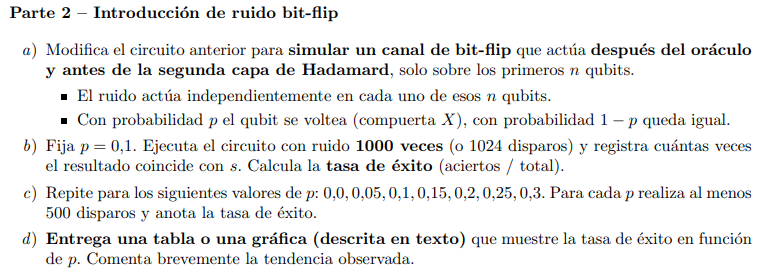

En esta segunda parte se estudiará cómo afecta el ruido al algoritmo de Bernstein–Vazirani. En particular, introduzco un ruido de tipo bit-flip, que consiste en voltear un qubit mediante una compuerta X con cierta probabilidad p.

La idea es simular este ruido de forma explícita, sin utilizar modelos de ruido predefinidos, para observar directamente cómo disminuye la probabilidad de recuperar correctamente la cadena secreta s.

a)

Para incorporar el ruido, parto del circuito ideal del algoritmo y agrego un proceso aleatorio que actúa sobre los n qubits del registro de entrada.

Después de aplicar el oráculo y la segunda capa de Hadamard, para cada qubit genero un número aleatorio en el intervalo [0,1). Si dicho número es menor que p, aplico una compuerta X, lo que representa un error de bit-flip y en caso contrario, el qubit permanece sin cambios.

Este procedimiento se realiza en cada ejecución, de modo que el patrón de ruido cambia en cada disparo.

In [8]:
# Con esta fun construyo Bernstein-Vazirani para una cadena s quee incorpora ruido bit-flip explícito sin usar código predefinido.

def construir_circuito_bv_con_ruido(s, p):
    n = len(s)
    aux = n
    qc = QuantumCircuit(n + 1, n)

    # Estado inicial |0>^n |1>
    qc.x(aux)

    # Primera capa de Hadamard
    for q in range(n + 1):
        qc.h(q)

    # Oráculo Uf
    for i, bit in enumerate(s):
        if bit == "1":
            qc.cx(i, aux)

    # Segunda capa de Hadamard
    for q in range(n):
        qc.h(q)

    # Ruido bit-flip en el registro de entrada generando un número aleatorio por qubit y aplicando X si es menor que p.
    for q in range(n):
        r = random.random()
        if r < p:
            qc.x(q)

    # Medición
    for q in range(n):
        qc.measure(q, n - 1 - q)

    return qc

b)

Ya con el circuito definido con ruido, voy a ejecutar múltiples simulaciones independientes. En cada disparo construiré un nuevo circuito con su propio patrón aleatorio de errores.

Para este caso fijo p=0.1 y realizo 1024 ejecuciones. Posteriormente cuento cuántas veces el resultado coincide con la cadena secreta s y calculo la tasa de éxito como la proporción de aciertos.

In [9]:
p = 0.10
shots_ruido = 1024
counts_ruido_p01 = Counter()
simulator = AerSimulator()

In [10]:
for _ in range(shots_ruido):
    qc = construir_circuito_bv_con_ruido(s, p)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1).result()
    measurement = list(result.get_counts().keys())[0]
    counts_ruido_p01[measurement] += 1

aciertos_p01 = counts_ruido_p01[s]
tasa_p01 = aciertos_p01 / shots_ruido

print("Cadena secreta s:", s)
print("p =", p)
print("Conteos ruidosos:")
print(dict(counts_ruido_p01))
print("Aciertos:", aciertos_p01, "de", shots_ruido)
print("Tasa de éxito:", tasa_p01)

Cadena secreta s: 1111
p = 0.1
Conteos ruidosos:
{'1111': 685, '1110': 73, '1011': 78, '0111': 67, '0011': 12, '1010': 6, '1101': 66, '0101': 9, '0110': 8, '1100': 9, '1001': 6, '1000': 1, '0001': 1, '0010': 2, '0100': 1}
Aciertos: 685 de 1024
Tasa de éxito: 0.6689453125


c)

Para entender mejor el efecto del ruido, repito el mismo procedimiento para distintos valores de p:

p=0.0,0.05,0.1,0.15,0.2,0.25,0.3.

En cada caso realizo 1000 ejecuciones independientes y calculo la tasa de éxito. Además, comparo los resultados con la aproximación teórica (1−p)
n
, que corresponde a la probabilidad de que ninguno de los n qubits sufra un error.

In [11]:
#Valores de p a estudiar
valores_p = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Núm de shoots independientes por cada valor de p
shots_por_p = 1000

# Lista donde se almacenarán los resultados finales y cada elemento tendrá: [p, aciertos, total, tasa_simulada, tasa_teorica]
tabla_resultados = []

# Recorremos cada p
for p_actual in valores_p:

    # pongo el cntador de resultados
    counts = Counter()

    # Ejecutamos múltiples veces
    for _ in range(shots_por_p):

        # Hago un nuevo circuito con ruido para este disparo
        qc = construir_circuito_bv_con_ruido(s, p_actual)

        # Transpilamos el circuito para el simulador
        compiled = transpile(qc, simulator)

        # Ejecutamos una sola vez (shots=1) para que el ruido sea distinto cada vez
        result = simulator.run(compiled, shots=1).result()

        # Obtenemos la medición
        measurement = list(result.get_counts().keys())[0]

        #Acumulamos en el contador
        counts[measurement] += 1

    #Veces que el resultado coincide con la cadena secreta s
    aciertos = counts[s]

    # Tasa de éxito experimental
    tasa = aciertos / shots_por_p

    # Aproximación teórica i.e. probabilidad de que ningún qubit sufra bit-flip
    tasa_teorica = (1 - p_actual) ** n

    # Guardamos todos los resultados en la tabla
    tabla_resultados.append([p_actual, aciertos, shots_por_p, tasa, tasa_teorica])

# Impresión de resultados en formato tabular
print("Tabla de resultados")
print("p     aciertos/total     tasa_simulada     aprox_(1-p)^n")

for fila in tabla_resultados:
    print(f"{fila[0]:.2f}  {fila[1]:4d}/{fila[2]}          {fila[3]:.4f}           {fila[4]:.4f}")

Tabla de resultados
p     aciertos/total     tasa_simulada     aprox_(1-p)^n
0.00  1000/1000          1.0000           1.0000
0.05   826/1000          0.8260           0.8145
0.10   638/1000          0.6380           0.6561
0.15   513/1000          0.5130           0.5220
0.20   414/1000          0.4140           0.4096
0.25   322/1000          0.3220           0.3164
0.30   235/1000          0.2350           0.2401


d)

Finalmente, represento gráficamente la tasa de éxito en función de p. Esto permite visualizar de manera clara cómo el ruido afecta el desempeño del algoritmo.

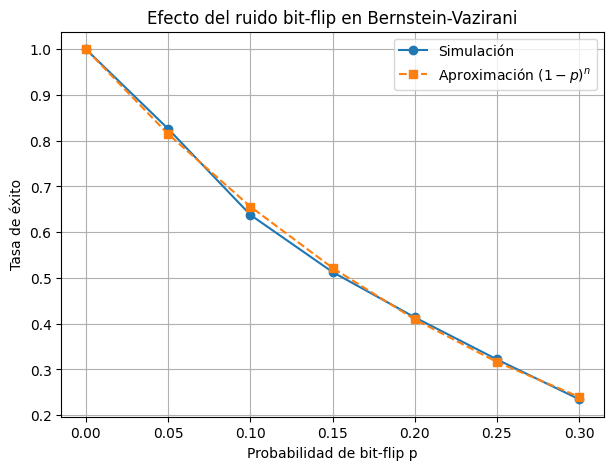

In [12]:
p_vals = [fila[0] for fila in tabla_resultados]
tasa_sim = [fila[3] for fila in tabla_resultados]
tasa_teo = [fila[4] for fila in tabla_resultados]

plt.figure(figsize=(7,5))
plt.plot(p_vals, tasa_sim, marker="o", label="Simulación")
plt.plot(p_vals, tasa_teo, linestyle="--", marker="s", label="Aproximación $(1-p)^n$")

plt.xlabel("Probabilidad de bit-flip p")
plt.ylabel("Tasa de éxito")
plt.title("Efecto del ruido bit-flip en Bernstein-Vazirani")
plt.grid(True)
plt.legend()
plt.show()

Y bueno, con base en los datos obtenidos, tenemos que la tasa de éxito cae de 1.00 a 0.235 al aumentar p de 0 a 0.30, lo que refleja claramente cómo el ruido degrada el resultado. Por ejemplo, para p=0.10 se obtiene una tasa de 0.638 (≈0.6561 teórico), lo que confirma que basta con que uno de los 4 qubits falle para perder la cadena correcta. En general, los valores simulados siguen muy de cerca a (1−p)
4
, mostrando que el comportamiento está dominado por la probabilidad de que ningún qubit sufra un error.

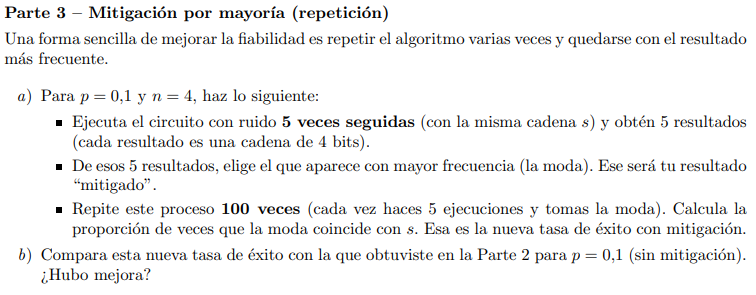

a)

In [13]:
# Parámetros
p_mitigacion = 0.10
repeticiones_por_bloque = 5
num_bloques = 100

# Contadores
aciertos_mitigados = 0
resultados_mitigados = []

# Repetimos el proceso completo
for _ in range(num_bloques):

    resultados_bloque = []

    # las 5 ejecuciones independientes con ruido
    for _ in range(repeticiones_por_bloque):
        qc = construir_circuito_bv_con_ruido(s, p_mitigacion)
        compiled = transpile(qc, simulator)
        result = simulator.run(compiled, shots=1).result()
        measurement = list(result.get_counts().keys())[0]
        resultados_bloque.append(measurement)

    # Por del bloque
    conteo_bloque = Counter(resultados_bloque)
    moda = conteo_bloque.most_common(1)[0][0]

    resultados_mitigados.append(moda)

    # Verificación contra s
    if moda == s:
        aciertos_mitigados += 1

# Tasa de éxito con mitigación
tasa_mitigada = aciertos_mitigados / num_bloques

print("Cadena secreta s:", s)
print("p =", p_mitigacion)
print("Tasa sin mitigación para p=0.1:", tasa_p01)
print("Aciertos mitigados:", aciertos_mitigados, "de", num_bloques)
print("Tasa con mitigación:", tasa_mitigada)
print("Conteo de resultados mitigados:")
print(dict(Counter(resultados_mitigados)))

Cadena secreta s: 1111
p = 0.1
Tasa sin mitigación para p=0.1: 0.6689453125
Aciertos mitigados: 89 de 100
Tasa con mitigación: 0.89
Conteo de resultados mitigados:
{'1111': 89, '1101': 4, '1011': 3, '0111': 2, '1110': 2}


b)

In [14]:
print("Comparación para p = 0.1")
print("Tasa sin:", tasa_p01)
print("Tasa con:", tasa_mitigada)

if tasa_mitigada > tasa_p01:
    print("Sí hubo mejora.")
else:
    print("No hubo mejora.")

Comparación para p = 0.1
Tasa sin: 0.6689453125
Tasa con: 0.89
Sí hubo mejora.


La mitigación por mayoría mejora  la tasa de éxito, pasando de 0.669 a 0.89, ya que al repetir el experimento los errores aislados se diluyen y la cadena correcta sigue siendo la más frecuente.

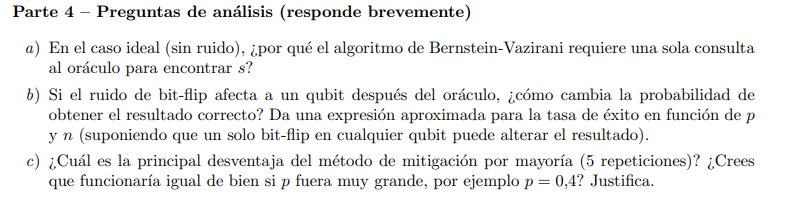

a) En el caso ideal, Bernstein–Vazirani requiere una sola consulta al oráculo porque la fase introducida por $f(x)=s\cdot x$ queda codificada en la superposición del registro de entrada. Después de aplicar la segunda capa de Hadamard, esa información se transforma directamente en la cadena $s$, por lo que la medición entrega el resultado correcto de forma determinística.

b) Si el ruido bit-flip puede alterar cualquiera de los $n$ qubits, la probabilidad de obtener la cadena correcta disminuye porque basta con que un solo bit cambie para que el resultado ya no coincida con $s$. Una aproximación para la tasa de éxito es

$$\text{P}_{\text{éxito}} \approx (1-p)^n,$$

que representa la probabilidad de que ningún qubit sufra un bit-flip.

c) La principal desventaja de la mitigación por mayoría es que aumenta el costo computacional, porque en vez de ejecutar el algoritmo una vez, se ejecuta cinco veces por cada resultado mitigado. Para $p=0.4$ no funcionaría igual de bien, ya que el ruido sería demasiado alto y la cadena correcta dejaría de aparecer con suficiente frecuencia como para dominar la moda.